In [ ]:
### Markdown ## 🔍 Headline Insight

Customer value in this dataset is relatively uniform and not strongly influenced by common factors such as purchase frequency, product category, seasonality, or customer satisfaction.

This suggests that revenue is evenly distributed across customers, and that traditional behavioral variables alone are insufficient to explain high-value customers. More advanced segmentation or additional data would be required to identify meaningful drivers of customer value.

In [44]:
# Import pandas for data manipulation and analysis
# Import matplotlib for data visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv(r"C:\Users\teba\Documents\python\2\archive\shopping_behavior_updated (1).csv")

In [46]:

#view data set
df


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,No,24,Venmo,Weekly


In [47]:
# Display summary of dataset (data types, non-null count

# Check for missing values in each column

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Discount Applied        3900 non-null   object 
 13  Previous Purchases      3900 non-null   int64  
 14  Payment Method          3900 non-null   

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [48]:
# Standardize column names: remove spaces, lowercase, replace spaces with underscores

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [49]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_(usd)   3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  discount_applied        3900 non-null   object 
 13  previous_purchases      3900 non-null   int64  
 14  payment_method          3900 non-null   

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
discount_applied          0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [50]:
# Convert key columns to numeric (invalid values become NaN)
# Convert key columns to numeric (invalid values become NaN)

df["purchase_amount_(usd)"] = pd.to_numeric(df["purchase_amount_(usd)"], errors="coerce")
df["previous_purchases"] = pd.to_numeric(df["previous_purchases"], errors="coerce")
df["review_rating"] = pd.to_numeric(df["review_rating"], errors="coerce")

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_(usd)   3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  discount_applied        3900 non-null   object 
 13  previous_purchases      3900 non-null   int64  
 14  payment_method          3900 non-null   

In [52]:
# Standardize text fields to avoid duplicates caused by case or spacing

df["category"] = df["category"].str.lower().str.strip()
df["payment_method"] = df["payment_method"].str.lower().str.strip()
df["season"] = df["season"].str.lower().str.strip()

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_(usd)   3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3900 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  discount_applied        3900 non-null   object 
 13  previous_purchases      3900 non-null   int64  
 14  payment_method          3900 non-null   

In [54]:
df


,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,review_rating,subscription_status,discount_applied,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,clothing,53,Kentucky,L,Gray,winter,3.1,Yes,Yes,14,venmo,Fortnightly
1,2,19,Male,Sweater,clothing,64,Maine,L,Maroon,winter,3.1,Yes,Yes,2,cash,Fortnightly
2,3,50,Male,Jeans,clothing,73,Massachusetts,S,Maroon,spring,3.1,Yes,Yes,23,credit card,Weekly
3,4,21,Male,Sandals,footwear,90,Rhode Island,M,Maroon,spring,3.5,Yes,Yes,49,paypal,Weekly
4,5,45,Male,Blouse,clothing,49,Oregon,M,Turquoise,spring,2.7,Yes,Yes,31,paypal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,clothing,28,Virginia,L,Turquoise,summer,4.2,No,No,32,venmo,Weekly
3896,3897,52,Female,Backpack,accessories,49,Iowa,L,White,spring,4.5,No,No,41,bank transfer,Bi-Weekly
3897,3898,46,Female,Belt,accessories,33,New Jersey,L,Green,spring,2.9,No,No,24,venmo,Quarterly
3898,3899,44,Female,Shoes,footwear,77,Minnesota,S,Brown,summer,3.8,No,No,24,venmo,Weekly


In [55]:
# Create a new column to estimate customer value (spend × purchase frequency)

df["customer_value"] = df["purchase_amount_(usd)"] * df["previous_purchases"]

In [56]:
# Convert purchase frequency categories into numeric scores for analysis

def freq(x):
    x = x.lower()
    if x == "weekly":
        return 4
    elif x == "fortnightly":
        return 3
    elif x == "monthly":
        return 2
    else:
        return 1

df["frequency_score"] = df["frequency_of_purchases"].apply(freq)

In [57]:
# Segment customers based on value and engagement level

def segment(row):
    if row["customer_value"] >= 300 and row["frequency_score"] >= 3:
        return "VIP"
    elif row["customer_value"] >= 200:
        return "High Value"
    elif row["customer_value"] >= 100:
        return "Mid Value"
    else:
        return "Low Value"

df["segment"] = df.apply(segment, axis=1)

In [58]:
#review changes
df.info


<bound method DataFrame.info of       customer_id  age  gender item_purchased     category  \
0               1   55    Male         Blouse     clothing   
1               2   19    Male        Sweater     clothing   
2               3   50    Male          Jeans     clothing   
3               4   21    Male        Sandals     footwear   
4               5   45    Male         Blouse     clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     clothing   
3896         3897   52  Female       Backpack  accessories   
3897         3898   46  Female           Belt  accessories   
3898         3899   44  Female          Shoes     footwear   
3899         3900   52  Female        Handbag  accessories   

      purchase_amount_(usd)       location size      color  season  \
0                        53       Kentucky    L       Gray  winter   
1                        64          Maine    L     Maroon  winter   
2            

In [59]:
df.head()
df["segment"].value_counts()

segment
High Value    2670
VIP            944
Mid Value      150
Low Value      136
Name: count, dtype: int64

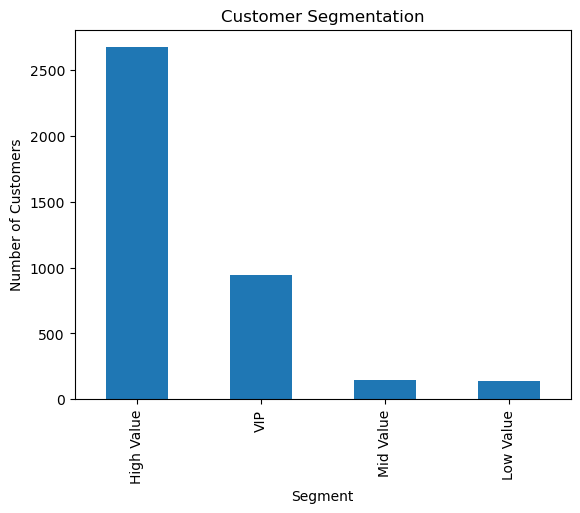

In [60]:
# Plot customer segmentation distribution
df["segment"].value_counts().plot(kind="bar")

# Add title and labels for clarity
plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [ ]:
### Insight

- The majority of customers fall into the High Value segment.
- VIP customers are significantly fewer but represent an opportunity for growth.
- Low-value customers contribute minimally to the overall customer base.

### Business Implication

- Focus should be placed on converting high-value customers into VIPs.
- Retention strategies should prioritize high-value segments.

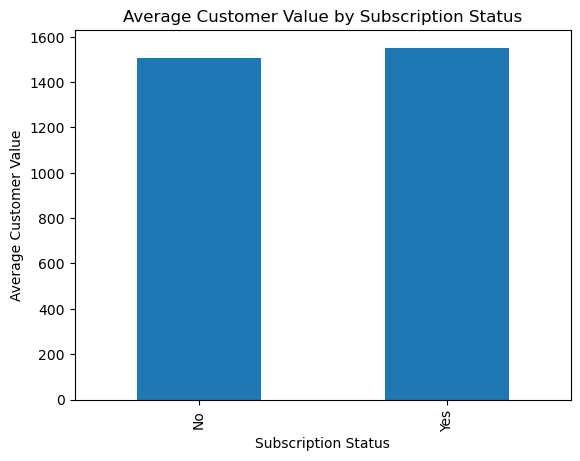

In [65]:
# Calculate average customer value by subscription status
subscription_value = df.groupby("subscription_status")["customer_value"].mean()

# Plot comparison
subscription_value.plot(kind="bar")

# Title reflects comparison of subscribed vs non-subscribed users
plt.title("Average Customer Value by Subscription Status")

# Subscription categories on x-axis
plt.xlabel("Subscription Status")

# Average value on y-axis
plt.ylabel("Average Customer Value")

# Show chart
plt.show()

In [ ]:
### Insight

- There is little difference in customer value between subscribers and non-subscribers.

### Business Implication

- The current subscription model is not effectively increasing customer value.
- The business should reconsider or enhance subscription benefits.

<Axes: xlabel='category'>

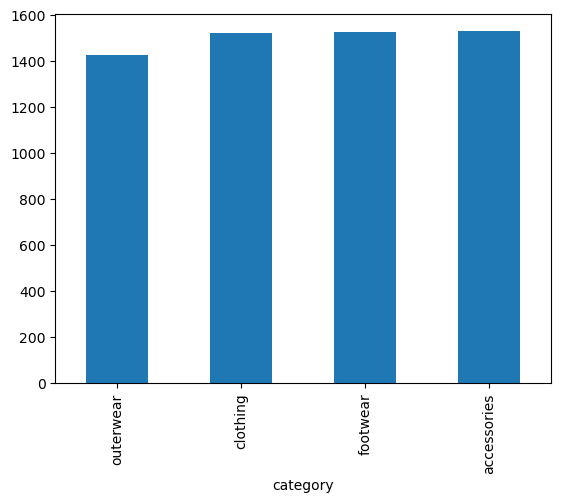

In [66]:

df.groupby("category")["customer_value"].mean().sort_values().plot(kind="bar")

In [ ]:
###mardkdown

<Axes: xlabel='payment_method'>

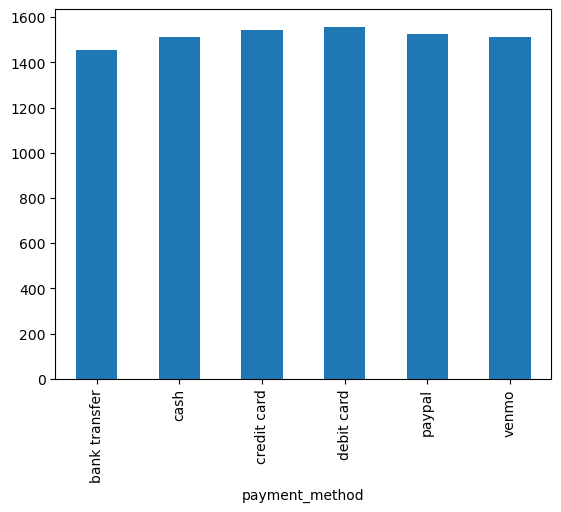

In [67]:
df.groupby("payment_method")["customer_value"].mean().plot(kind="bar")

In [ ]:
###Markdown

<Axes: xlabel='frequency_of_purchases'>

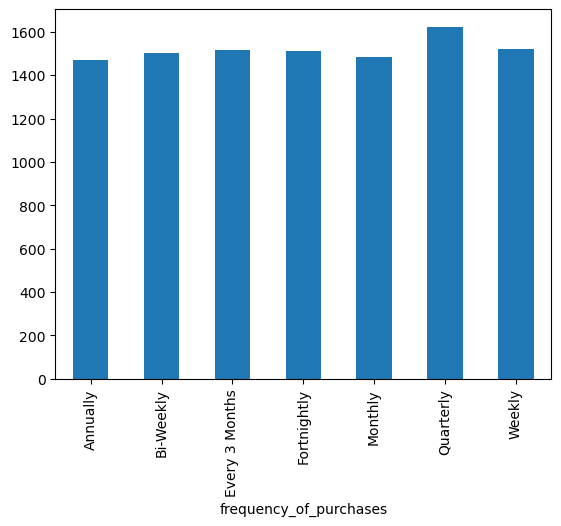

In [68]:
df.groupby("frequency_of_purchases")["customer_value"].mean().plot(kind="bar")

In [ ]:
#### Markdown

<Axes: xlabel='review_rating'>

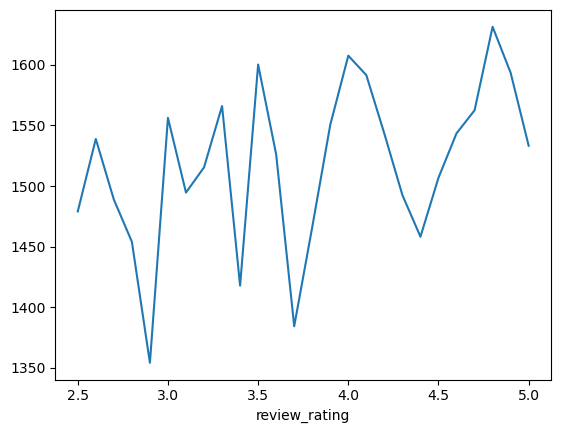

In [69]:
df.groupby("review_rating")["customer_value"].mean().plot(kind="line")

In [ ]:
###markdown

<Axes: xlabel='season'>

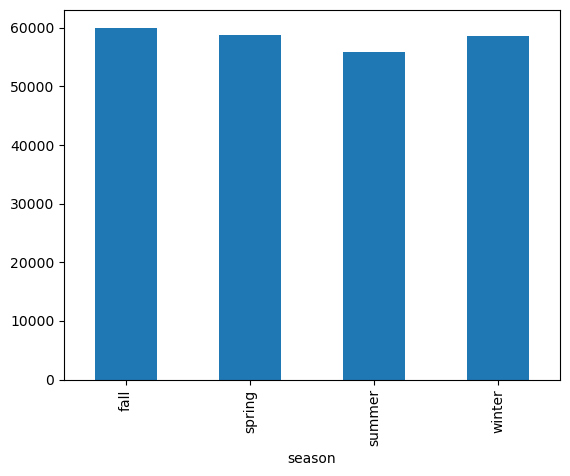

In [70]:
df.groupby("season")["purchase_amount_(usd)"].sum().plot(kind="bar")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

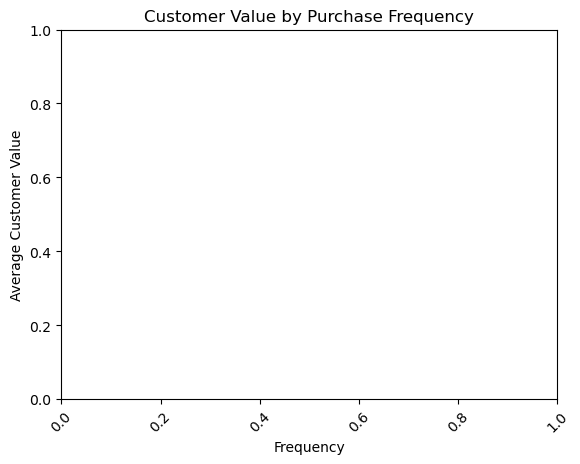

In [71]:
plt.title("Customer Value by Purchase Frequency")
plt.xlabel("Frequency")
plt.ylabel("Average Customer Value")
plt.xticks(rotation=45)

In [72]:
df.groupby("segment")["customer_value"].describe()

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
High Value,2670.0,1600.313109,1094.261016,200.0,728.0,1340.0,2278.75,4900.0
Low Value,136.0,65.514706,22.470058,21.0,49.0,70.5,83.00,99.0
Mid Value,150.0,153.460000,28.674435,100.0,128.0,155.0,180.00,198.0
VIP,944.0,1710.757415,1054.602310,310.0,859.5,1498.5,2376.00,5000.0


In [ ]:
###MMarkdown The dataset lacks time-based variables, limiting retention analysis
No clear drivers of customer value were identified
Future analysis should include customer lifecycle and behavioral tracking

## 📊 Key Findings

- Customer value is consistently distributed across most variables, with no single dominant driver identified.
- Product categories show similar average customer value, indicating a diversified revenue base.
- Purchase frequency has minimal impact on overall customer value, suggesting that frequent purchases do not necessarily translate into higher spending.
- Subscription status does not significantly influence customer value, indicating that the current subscription model may not be effective.
- Customer satisfaction (review ratings) does not show a strong or consistent relationship with spending behavior.
- Revenue remains stable across seasons, suggesting that the business is not significantly affected by seasonality.

Overall, the analysis indicates that customer value is not driven by simple observable factors and requires deeper analytical approaches to uncover meaningful patterns.